# exp_001 — Context measurement

This notebook is executable against the strongest available evidence. If a measured `main` manifest exists it is used; otherwise an unqualified run automatically displays the committed fixture smoke as a **harness-only** result. Set `EXP001_PHASE=main` to require the declared full real-model run, `EXP001_PHASE=feasibility` to inspect the bounded 64K/128K/262K Q8 probe, or `EXP001_PHASE=pilot-matched` to inspect the committed reduced real-model baseline.

The smoke result validates context construction, evidence offsets, storage, and processing. It is not a Qwen capability result. Repeated greedy prompts are not independent accuracy observations; independent task IDs are the capability denominator. The operational real-model reference is Q8_0 through llama.cpp, matching exp_002/exp_003; a Transformers run remains a separately labelled full-precision reference and must not be pooled with GGUF values.

In [1]:
import os
import sys
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd

ROOT = next(candidate for candidate in [Path.cwd(), *Path.cwd().parents] if (candidate / 'src').is_dir() and (candidate / 'experiments').is_dir())
EXPERIMENT_ROOT = ROOT / 'experiments/exp_001-context_measurement'
RESULTS_DIR = Path(os.environ.get('EXP001_RESULTS_DIR', EXPERIMENT_ROOT / 'results'))
REQUESTED_PHASE = os.environ.get('EXP001_PHASE', 'main')
PHASE = REQUESTED_PHASE
if 'EXP001_PHASE' not in os.environ:
    for candidate_phase in ('main', 'pilot-matched', 'feasibility', 'smoke'):
        if (RESULTS_DIR / 'manifests' / f'{candidate_phase}.json').is_file():
            PHASE = candidate_phase
            break
ALLOW_FIXTURE = os.environ.get('EXP001_ALLOW_FIXTURE', '1' if PHASE == 'smoke' else '0') == '1'
if ALLOW_FIXTURE and PHASE != 'smoke':
    raise ValueError('EXP001_ALLOW_FIXTURE=1 is permitted only for PHASE=smoke')
sys.path.insert(0, str(ROOT / 'src'))
sys.path.insert(0, str(EXPERIMENT_ROOT))
from analyze import regenerate
from llm_lab.analysis import classify_feasibility_by_length, effective_context_by_task, effective_context_by_task_and_position, position_curve_rows, position_gap_rows, task_level_wilson
from llm_lab.evaluation import load_trial_results

MANIFEST_PATH = RESULTS_DIR / 'manifests' / f'{PHASE}.json'
FIGURES_DIR = RESULTS_DIR / 'figures'
analysis_ready = MANIFEST_PATH.is_file()
if not analysis_ready:
    raise FileNotFoundError(f'required {PHASE} manifest is missing: {MANIFEST_PATH}')
regeneration = regenerate(MANIFEST_PATH, allow_fixture=ALLOW_FIXTURE)
manifest = __import__('json').loads(MANIFEST_PATH.read_text(encoding='utf-8'))
summary_rows = regeneration['summary_rows']
feasibility_rows = regeneration.get('feasibility_rows', [])
task_metric_rows = []
for trial in load_trial_results(regeneration['raw_results']):
    score = trial.score
    task_metric_rows.append({
        'task_id': trial.task_id,
        'task_type': trial.input.get('task_type'),
        'target_context_tokens': trial.input.get('target_context_tokens'),
        'requested_evidence_position': trial.input.get('requested_evidence_position'),
        'attempted_n': 1,
        'exact_correct': score.get('exact_correct'),
        'answer_bearing_correct': score.get('answer_bearing_correct'),
        'format_valid': score.get('format_valid'),
        'end_to_end_success': score.get('correct') is True,
    })
task_uncertainty = task_level_wilson(
    task_metric_rows,
    group_keys=('task_type', 'target_context_tokens', 'requested_evidence_position'),
    metric_fields={'end_to_end': 'end_to_end_success', 'exact': 'exact_correct', 'answer_bearing': 'answer_bearing_correct', 'format_valid': 'format_valid'},
)
expected_scorer='calibrated.v1'
if any(row.get('scorer_version') != expected_scorer for row in summary_rows):
    raise ValueError('summary contains a scorer version outside calibrated.v1')
available_summary_rows = [row for row in summary_rows if row.get('analysis_status', 'available') == 'available']
planned_lengths = tuple(manifest['context_lengths'])
planned_positions = tuple(manifest['evidence_positions'])
planned_tasks = tuple(manifest['task_types'])
task_counts = dict(manifest.get('independent_task_n_by_type', {}))
claim_blockers = []
model_record = manifest.get('model') or {}
runtime_record = manifest.get('runtime') or {}
if PHASE == 'main':
    if manifest.get('backend') != 'llama.cpp': claim_blockers.append('main Qwen baseline must use the operational llama.cpp backend')
    if model_record.get('id') != 'Qwen/Qwen3.8-27B': claim_blockers.append('main baseline model identity is not the pinned Qwen revision')
    if not model_record.get('revision') or not model_record.get('tokenizer_revision'): claim_blockers.append('main baseline must pin model and tokenizer revisions')
    if not runtime_record.get('version'): claim_blockers.append('main baseline must record the llama.cpp runtime version')
    artifact_record = runtime_record.get('artifact') or {}
    if not artifact_record.get('sha256') or not artifact_record.get('size_bytes'): claim_blockers.append('main baseline must record the Q8_0 artifact hash and size')
    if 'q8_0' not in str(artifact_record.get('uri', '')).lower(): claim_blockers.append('main baseline must use the pinned Q8_0 reference artifact')
if PHASE == 'main':
    if manifest['backend'] == 'fixture': claim_blockers.append('fixture backend is harness-only')
    if int(manifest.get('capability_repeats', manifest.get('repeats', 0))) != 1: claim_blockers.append('capability conclusions require one run per independent task')
    if tuple(planned_lengths) != (8192, 32768, 65536, 131072): claim_blockers.append('required context lengths are incomplete')
    if tuple(planned_positions) != (0.05, 0.25, 0.5, 0.75, 0.95): claim_blockers.append('required evidence positions are incomplete')
    if any(int(task_counts.get(task_type, 0)) < 10 for task_type in planned_tasks): claim_blockers.append('each task family needs at least 10 independent tasks')
    if regeneration['excluded_cell_n'] or any(row.get('analysis_status') != 'available' for row in summary_rows): claim_blockers.append('all declared cells must record complete attempts without exclusions')
elif PHASE == 'feasibility':
    if manifest.get('backend') != 'llama.cpp': claim_blockers.append('feasibility probe must use llama.cpp Q8')
    if len(feasibility_rows) != len(planned_lengths): claim_blockers.append('every feasibility context length needs a classification')
    claim_blockers.append('feasibility is bounded to the recorded environment and protocol; it is not a general effective-context claim')
else:
    claim_blockers.append('main or feasibility phase is required')
claim_ready = not claim_blockers
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
print({'phase': PHASE, 'backend': manifest['backend'], 'evidence_status': 'harness-only' if manifest['backend'] == 'fixture' else 'measured-model', 'claim_ready': claim_ready, 'claim_blockers': claim_blockers, 'raw_sha256': regeneration['raw_results_sha256'], 'trial_n': regeneration['trial_n'], 'summary_rows': len(summary_rows), 'excluded_cells': regeneration['excluded_cell_n'], 'baseline_limited': regeneration['baseline_limited_task_types']})

{'phase': 'pilot-matched', 'backend': 'llama.cpp', 'evidence_status': 'measured-model', 'claim_ready': False, 'claim_blockers': ['main or feasibility phase is required'], 'raw_sha256': '9f3c567e94051b4bed96716f4fedc4b0a242af961014162f6e34b6a44f0ebb59', 'trial_n': 60, 'summary_rows': 6, 'excluded_cells': 0, 'baseline_limited': ['literal_retrieval', 'semantic_retrieval']}


In [2]:
if analysis_ready:
    coverage = pd.DataFrame([{key: row.get(key) for key in ('task_type', 'target_context_tokens', 'requested_evidence_position', 'attempted_n', 'completed_n', 'error_n', 'scored_n', 'end_to_end_success', 'exact_accuracy', 'answer_bearing_accuracy', 'format_validity', 'scored_accuracy', 'analysis_status')} for row in position_curve_rows(summary_rows)])
    display(coverage)
    display(pd.DataFrame(task_uncertainty))
    print('Wilson intervals use independent task IDs; runtime/invalid-output attempts remain in the denominator.')
    if manifest['backend'] == 'fixture':
        print('Interpretation boundary: fixture smoke checks the harness only; it is not Qwen evidence.')

,task_type,target_context_tokens,requested_evidence_position,attempted_n,completed_n,error_n,scored_n,end_to_end_success,exact_accuracy,answer_bearing_accuracy,format_validity,scored_accuracy,analysis_status
0,literal_retrieval,8192,0.5,10,10,0,10,0.2,0.2,1.0,0.2,0.2,available
1,literal_retrieval,32768,0.5,10,10,0,10,0.6,0.6,1.0,0.6,0.6,available
2,multi_hop,8192,0.5,10,10,0,10,0.8,0.8,1.0,0.8,0.8,available
3,multi_hop,32768,0.5,10,10,0,10,0.9,0.9,1.0,0.9,0.9,available
4,semantic_retrieval,8192,0.5,10,10,0,10,0.4,0.4,1.0,0.9,0.4,available
5,semantic_retrieval,32768,0.5,10,10,0,10,0.3,0.3,1.0,0.8,0.3,available


,task_type,target_context_tokens,requested_evidence_position,task_n,attempted_n,end_to_end_success_n,end_to_end_rate,end_to_end_ci_low,end_to_end_ci_high,exact_success_n,...,exact_ci_low,exact_ci_high,answer_bearing_success_n,answer_bearing_rate,answer_bearing_ci_low,answer_bearing_ci_high,format_valid_success_n,format_valid_rate,format_valid_ci_low,format_valid_ci_high
0,literal_retrieval,32768,0.5,10,10,6,0.6,0.312670,0.831822,6,...,0.312670,0.831822,10,1.0,0.72246,1.0,6,0.6,0.312670,0.831822
1,literal_retrieval,8192,0.5,10,10,2,0.2,0.056681,0.509843,2,...,0.056681,0.509843,10,1.0,0.72246,1.0,2,0.2,0.056681,0.509843
2,multi_hop,32768,0.5,10,10,9,0.9,0.595844,0.982124,9,...,0.595844,0.982124,10,1.0,0.72246,1.0,9,0.9,0.595844,0.982124
3,multi_hop,8192,0.5,10,10,8,0.8,0.490157,0.943319,8,...,0.490157,0.943319,10,1.0,0.72246,1.0,8,0.8,0.490157,0.943319
4,semantic_retrieval,32768,0.5,10,10,3,0.3,0.107789,0.603227,3,...,0.107789,0.603227,10,1.0,0.72246,1.0,8,0.8,0.490157,0.943319
5,semantic_retrieval,8192,0.5,10,10,4,0.4,0.168178,0.687330,4,...,0.168178,0.687330,10,1.0,0.72246,1.0,9,0.9,0.595844,0.982124


Wilson intervals use independent task IDs; runtime/invalid-output attempts remain in the denominator.


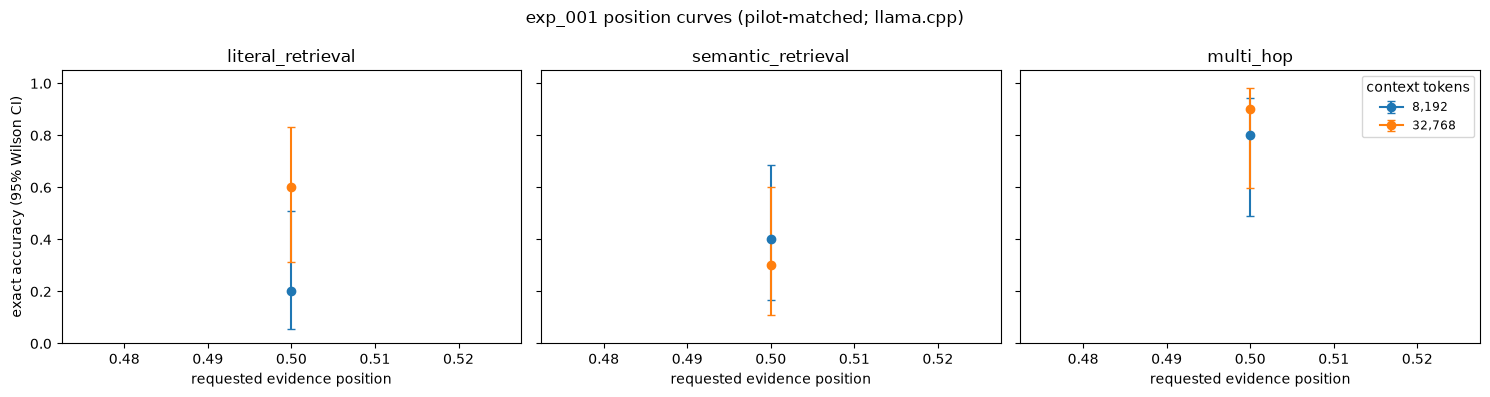

In [3]:
if analysis_ready:
    fig, axes = plt.subplots(1, len(planned_tasks), figsize=(15, 4), sharey=True)
    axes = [axes] if len(planned_tasks) == 1 else axes
    for axis, task_type in zip(axes, planned_tasks):
        for context_tokens in planned_lengths:
            points = sorted((row for row in task_uncertainty if row['task_type'] == task_type and row['target_context_tokens'] == context_tokens), key=lambda row: row['requested_evidence_position'])
            axis.errorbar(
                [row['requested_evidence_position'] for row in points],
                [row['exact_rate'] for row in points],
                yerr=[[row['exact_rate'] - row['exact_ci_low'] for row in points], [row['exact_ci_high'] - row['exact_rate'] for row in points]],
                marker='o', capsize=3, label=f'{context_tokens:,}',
            )
        axis.set_title(task_type)
        axis.set_xlabel('requested evidence position')
        axis.set_ylim(0, 1.05)
    axes[0].set_ylabel('exact accuracy (95% Wilson CI)')
    axes[-1].legend(title='context tokens', fontsize='small')
    fig.suptitle(f'exp_001 position curves ({PHASE}; {manifest["backend"]})')
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / 'position-curves.png', dpi=160)
    plt.show()

Position-gap analysis is insufficient_data: the run does not include beginning/middle/end positions.


,task_type,capability_metric,baseline_accuracy,status,crossing_context_tokens,effective_context_tokens,largest_tested_context_tokens
0,literal_retrieval,end_to_end_success,0.2,baseline_limited,None,None,32768
1,multi_hop,end_to_end_success,0.8,right_censored,None,None,32768
2,semantic_retrieval,end_to_end_success,0.4,baseline_limited,None,None,32768


,task_type,evidence_position,baseline_accuracy,status,crossing_context_tokens,effective_context_tokens
0,literal_retrieval,0.5,0.2,baseline_limited,None,None
1,multi_hop,0.5,0.8,right_censored,None,None
2,semantic_retrieval,0.5,0.4,baseline_limited,None,None


Effective-context values are descriptive only when the baseline gate is satisfied; smoke values remain harness-only.


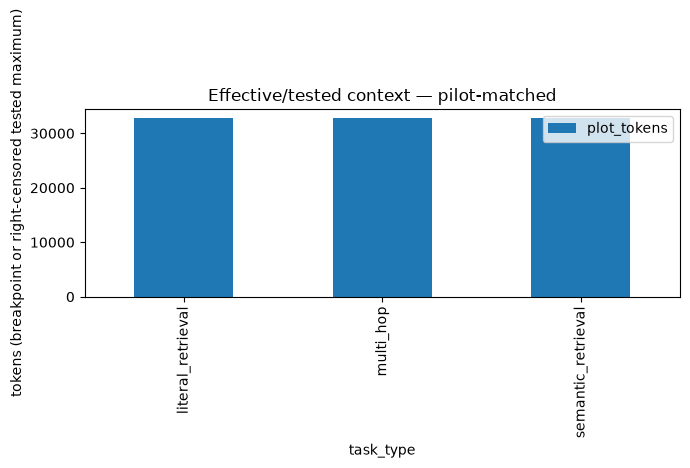

In [4]:
if analysis_ready:
    if PHASE == 'feasibility':
        display(pd.DataFrame(feasibility_rows)[['target_context_tokens', 'classification', 'attempted_n', 'completed_n', 'answer_bearing_n', 'timeout_n', 'runtime_failure_n', 'reason']])
        print('Feasibility classifications are bounded to this Q8 artifact, runtime, hardware, task set, and fixed timeout; they are not a general effective-context claim.')
    else:
        if all(position in planned_positions for position in (0.05, 0.50, 0.95)):
            gap_rows = position_gap_rows(summary_rows)
            gap_frame = pd.DataFrame(gap_rows)
            display(gap_frame)
            gap_plot = gap_frame.pivot(index='target_context_tokens', columns='task_type', values='position_gap')
            gap_plot.plot(marker='o', figsize=(7, 4), title=f'Position gap (edge − middle) — {PHASE}')
            plt.xlabel('context tokens')
            plt.ylabel('end-to-end success gap')
            plt.tight_layout()
            plt.savefig(FIGURES_DIR / 'position-gap-vs-context.png', dpi=160)
        else:
            gap_rows = []
            print('Position-gap analysis is insufficient_data: the run does not include beginning/middle/end positions.')
        baseline_length = int(manifest['effective_context']['baseline_length'])
        baseline_gate = float(manifest['effective_context']['baseline_accuracy_gate'])
        alpha = float(manifest['effective_context']['alpha'])
        effective = effective_context_by_task(summary_rows, baseline_context_tokens=baseline_length, alpha=alpha, minimum_baseline_accuracy=baseline_gate)
        effective_by_position = effective_context_by_task_and_position(summary_rows, baseline_context_tokens=baseline_length, alpha=alpha, minimum_baseline_accuracy=baseline_gate)
        display(pd.DataFrame(effective)[['task_type', 'capability_metric', 'baseline_accuracy', 'status', 'crossing_context_tokens', 'effective_context_tokens', 'largest_tested_context_tokens']])
        display(pd.DataFrame(effective_by_position)[['task_type', 'evidence_position', 'baseline_accuracy', 'status', 'crossing_context_tokens', 'effective_context_tokens']])
        effective_frame = pd.DataFrame(effective)
        effective_frame['plot_tokens'] = effective_frame['effective_context_tokens'].fillna(effective_frame['largest_tested_context_tokens'])
        effective_frame.plot(x='task_type', y='plot_tokens', kind='bar', figsize=(7, 4), title=f'Effective/tested context — {PHASE}')
        plt.ylabel('tokens (breakpoint or right-censored tested maximum)')
        plt.tight_layout()
        plt.savefig(FIGURES_DIR / 'effective-context-vs-context.png', dpi=160)
        print('Effective-context values are descriptive only when the baseline gate is satisfied; smoke values remain harness-only.')

In [5]:
if analysis_ready:
    systems = pd.DataFrame([{key: row.get(key) for key in ('task_type', 'target_context_tokens', 'median_stream_ttft_s', 'median_prefill_tokens_per_second', 'median_decode_tokens_per_second', 'median_peak_memory_bytes')} for row in available_summary_rows])
    display(systems.head(20))
    if manifest['backend'] == 'fixture':
        print('Systems values above are fixture timing values and must not be presented as model performance.')

,task_type,target_context_tokens,median_stream_ttft_s,median_prefill_tokens_per_second,median_decode_tokens_per_second,median_peak_memory_bytes
0,literal_retrieval,8192,75.024608,None,None,3.117042e+10
1,literal_retrieval,32768,339.455287,None,None,3.122799e+10
2,multi_hop,8192,75.056983,None,None,3.119584e+10
3,multi_hop,32768,337.539027,None,None,3.124897e+10
4,semantic_retrieval,8192,75.016836,None,None,3.119580e+10
5,semantic_retrieval,32768,338.259805,None,None,3.122949e+10


## Presentation figures

The following figures read the named measured pilot and feasibility artifacts directly. They are designed for slide use: one claim per figure, direct count labels, and explicit protocol limitations.

In [6]:
from llm_lab.presentation import plot_exp001_presentation
presentation_figures = plot_exp001_presentation(RESULTS_DIR)
presentation_figures

['/Users/shotomorisaki/Engineering/qwen-meetup-tokyo/experiments/exp_001-context_measurement/results/figures/presentation-feasibility-boundary.png',
 '/Users/shotomorisaki/Engineering/qwen-meetup-tokyo/experiments/exp_001-context_measurement/results/figures/presentation-baseline-by-task.png']